<a href="https://colab.research.google.com/github/Pedro4Albuquerque/09-DIS-Disney-Dire-o-de-Volume/blob/main/PepilinesDisney2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline 1 | Carregamento dos Dados via API [DIS - Disney]

In [30]:

from typing import List
import requests
import pandas as pd

API_KEY = "YF91FPXACQJ396DA"
SYMBOL = "DIS"

url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={SYMBOL}&outputsize=compact&apikey={API_KEY}'
r = requests.get(url)
data = r.json()

dados = data["Time Series (Daily)"]

base_dis = pd.DataFrame.from_dict(
    dados,
    orient="index"
)

base_dis

,1. open,2. high,3. low,4. close,5. volume
2026-05-04,102.7400,103.0500,101.2700,101.3100,8400068
2026-05-01,104.4000,104.8325,102.9700,103.0800,5956945
2026-04-30,100.9100,104.1200,100.4200,103.7500,9203503
2026-04-29,100.9400,101.4800,100.6000,101.3000,5533717
2026-04-28,102.6600,103.2899,100.6100,101.4700,6409294
...,...,...,...,...,...
2025-12-15,110.7000,111.5500,108.5500,110.4900,14317985
2025-12-12,111.7300,113.3400,111.1500,111.6000,13059066
2025-12-11,109.2000,111.5600,109.1100,111.4600,13281383
2025-12-10,107.1200,109.6650,106.5800,108.8300,11237894


## Blibliotecas de Python

In [3]:
!pip -q install plotly
!pip -q install yellowbrick

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Pipeline 2 | Organização e Limpeza

In [5]:
base_dis.index = pd.to_datetime(base_dis.index)

base_dis = base_dis.rename(columns={
    "1. open": "Open",
    "2. high": "High",
    "3. low": "Low",
    "4. close": "Close",
    "5. volume": "Volume"
})

base_dis = base_dis.astype(float)

base_dis = base_dis.sort_index()

base_dis

,Open,High,Low,Close,Volume
2025-12-09,107.59,107.7450,106.55,107.02,8210364.0
2025-12-10,107.12,109.6650,106.58,108.83,11237894.0
2025-12-11,109.20,111.5600,109.11,111.46,13281383.0
2025-12-12,111.73,113.3400,111.15,111.60,13059066.0
2025-12-15,110.70,111.5500,108.55,110.49,14317985.0
...,...,...,...,...,...
2026-04-28,102.66,103.2899,100.61,101.47,6409294.0
2026-04-29,100.94,101.4800,100.60,101.30,5533717.0
2026-04-30,100.91,104.1200,100.42,103.75,9203503.0
2026-05-01,104.40,104.8325,102.97,103.08,5956945.0


# Pipeline 3 | Análise Exploratória

## Mostra informações gerais da tabela.

In [6]:
base_dis.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2025-12-09 to 2026-05-04
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    100 non-null    float64
 1   High    100 non-null    float64
 2   Low     100 non-null    float64
 3   Close   100 non-null    float64
 4   Volume  100 non-null    float64
dtypes: float64(5)
memory usage: 4.7 KB


## Gera estatísticas automáticas das colunas numéricas.

In [7]:
base_dis.describe()

,Open,High,Low,Close,Volume
count,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,105.642050,106.859745,104.623475,105.735200,1.067845e+07
std,5.801245,5.870626,5.837849,5.926811,4.826560e+06
min,92.890000,94.190000,92.185000,92.420000,4.606746e+06
25%,101.240000,101.885550,100.360000,101.317500,8.100944e+06
50%,105.250000,106.822500,104.105000,105.445000,9.625417e+06
75%,111.251250,112.800000,110.512500,111.347500,1.190189e+07
max,114.770000,116.030000,114.100000,115.880000,3.777850e+07


## Verifica valores vazios (NaN) na tabela.

In [8]:
base_dis.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0


# Pipeline 4 | Visualização de Dados

## Fechamento das ações

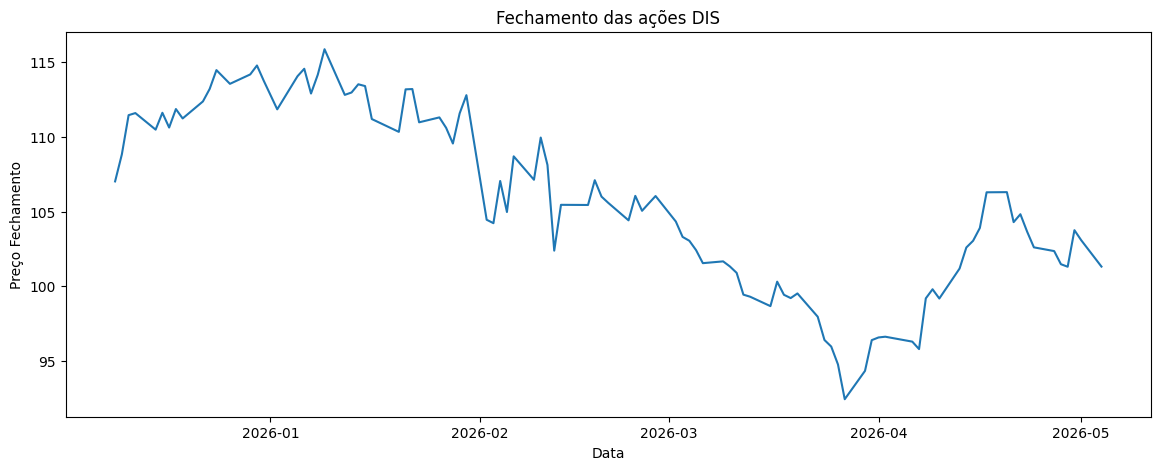

In [9]:
plt.figure(figsize=(14,5))

plt.plot(base_dis.index, base_dis["Close"])

plt.title("Fechamento das ações DIS")
plt.xlabel("Data")
plt.ylabel("Preço Fechamento")

plt.show()

## Volume negociado

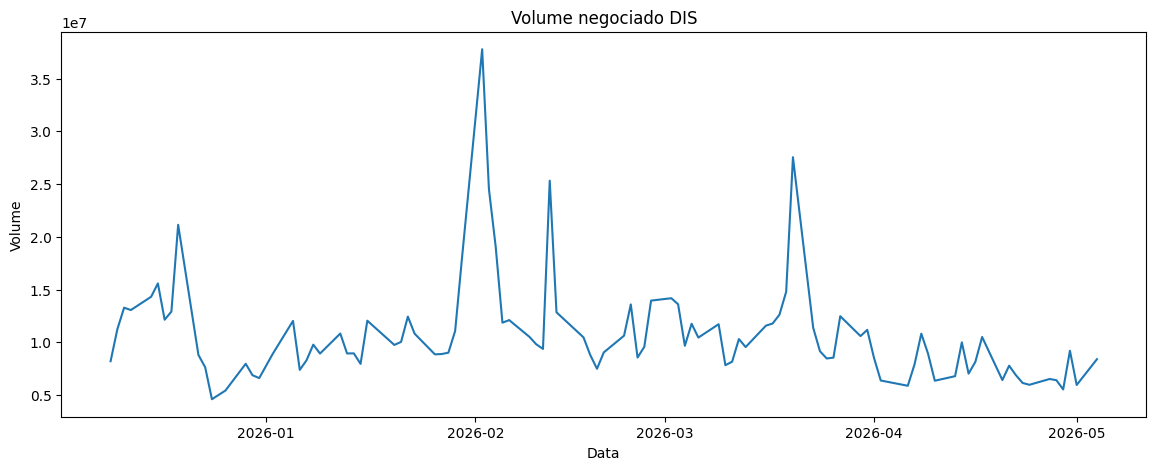

In [10]:
plt.figure(figsize=(14,5))

plt.plot(base_dis.index, base_dis["Volume"])

plt.title("Volume negociado DIS")
plt.xlabel("Data")
plt.ylabel("Volume")

plt.show()

## Correlação

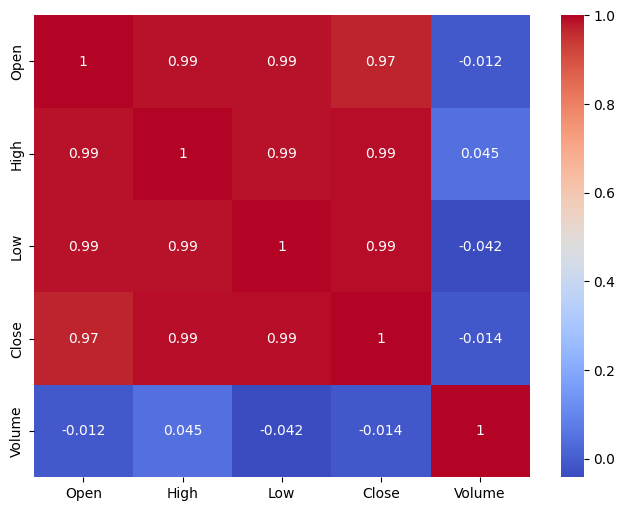

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    base_dis.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Pipeline 5 | Engenharia de Features

## Criação do alvo Y

In [12]:
base_dis["fechamento_anterior"] = base_dis["Close"].shift(1)

base_dis["direcao"] = np.where(
    base_dis["Close"] > base_dis["fechamento_anterior"],
    1,
    0
)

In [13]:
base_dis

,Open,High,Low,Close,Volume,fechamento_anterior,direcao
2025-12-09,107.59,107.7450,106.55,107.02,8210364.0,NaN,0
2025-12-10,107.12,109.6650,106.58,108.83,11237894.0,107.02,1
2025-12-11,109.20,111.5600,109.11,111.46,13281383.0,108.83,1
2025-12-12,111.73,113.3400,111.15,111.60,13059066.0,111.46,1
2025-12-15,110.70,111.5500,108.55,110.49,14317985.0,111.60,0
...,...,...,...,...,...,...,...
2026-04-28,102.66,103.2899,100.61,101.47,6409294.0,102.35,0
2026-04-29,100.94,101.4800,100.60,101.30,5533717.0,101.47,0
2026-04-30,100.91,104.1200,100.42,103.75,9203503.0,101.30,1
2026-05-01,104.40,104.8325,102.97,103.08,5956945.0,103.75,0


## Volume da véspera

In [14]:
base_dis["volume_anterior"] = base_dis["Volume"].shift(1)

## Removendo valores nulos

In [15]:
base_dis.dropna(inplace=True)

# Pipeline 6 | Separação X e Y

In [16]:
X_dis = base_dis[
    [
      "volume_anterior"
    ]
].values

Y_dis = base_dis["direcao"].values

# Pipeline 7 | Normalização

In [17]:
from sklearn.preprocessing import StandardScaler

scaler_dis = StandardScaler()

X_dis = scaler_dis.fit_transform(X_dis)

# Pipeline 8 | Treinamento

In [18]:
from sklearn.model_selection import train_test_split

X_treinamento, X_teste, Y_treinamento, Y_teste = train_test_split(
    X_dis,
    Y_dis,
    test_size=0.15,
    random_state=0,
    shuffle=False
)

X_treinamento.shape, X_teste.shape

((84, 1), (15, 1))

# Pipeline 9 | Treinamento GaussianNB

In [19]:
from sklearn.naive_bayes import GaussianNB

modelo_dis = GaussianNB()

modelo_dis.fit(
    X_treinamento,
    Y_treinamento
)

GaussianNB()

# Pipeline 10 | Previsões

In [20]:
previsoes = modelo_dis.predict(X_teste)

previsoes

array([0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

# Pipeline 11 | Avaliação

In [21]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Acurácia

In [22]:
accuracy_score(
    Y_teste,
    previsoes
)

0.7333333333333333

Matriz de Confusão

In [23]:
confusion_matrix(
    Y_teste,
    previsoes
)

array([[7, 1],
       [3, 4]])

Relatório

In [24]:
print(
    classification_report(
        Y_teste,
        previsoes
    )
)

              precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.80      0.57      0.67         7

    accuracy                           0.73        15
   macro avg       0.75      0.72      0.72        15
weighted avg       0.75      0.73      0.73        15



# Pipeline 12 | Yellowbrick

In [25]:
from yellowbrick.classifier import ConfusionMatrix

0.7333333333333333

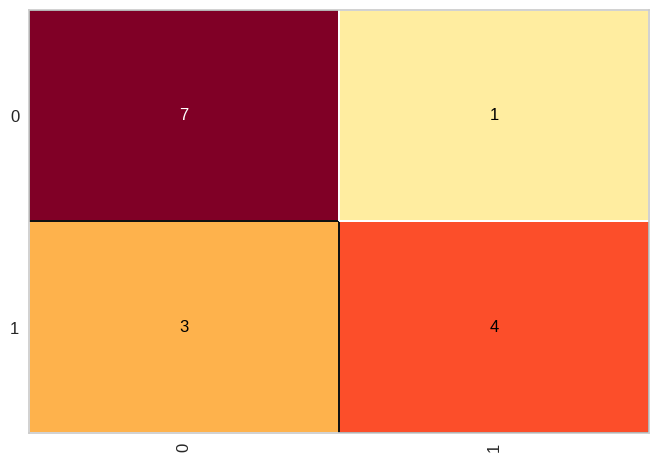

In [26]:
cm_dis = ConfusionMatrix(modelo_dis)

cm_dis.fit(
    X_treinamento,
    Y_treinamento
)

cm_dis.score(
    X_teste,
    Y_teste
)

Distribuição do alvo

<Axes: xlabel='direcao', ylabel='count'>

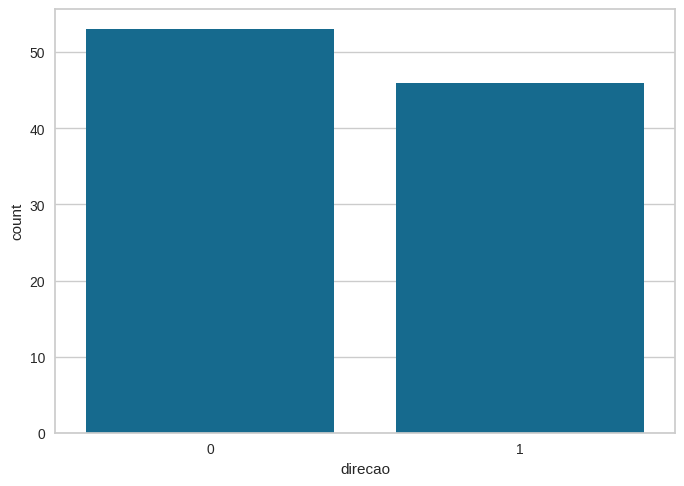

In [27]:
sns.countplot(x=base_dis["direcao"])

Gráfico interativo

In [28]:
grafico = px.line(
    base_dis,
    x=base_dis.index,
    y="Close",
    title="Fechamento DIS"
)

grafico.show()